# Gold's Loud Cousin \U0001F948
### If silver is just gold on leverage, why not hold more gold instead?

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Everyone in the metals trade says it: silver is gold with the volume turned up. That is a
checkable claim, and it has a sharp consequence — if it is exactly true then silver is
redundant, and you should hold gold and size it up instead.

> \U0001F4D3 **This is the plain-language layer.** The rolling betas, the residual factor
> loadings and the drag arithmetic are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is silver correlated with gold? | Strongly. |
| Is its beta about 1.7-1.8? | On average, yes. |
| Is that beta *stable*? | No — it roams across a range wider than the number itself. |
| Would levered gold have replaced silver? | No. The tracking error is bigger than most people's whole risk budget. |

## 1 · The claim

In [2]:
from loudcousin import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
common = rets[[data.GOLD, data.SILVER, data.DOLLAR, data.TIPS, data.INDUSTRIAL,
               data.CASH]].dropna()
g, s = common[data.GOLD], common[data.SILVER]
b = st.full_sample_beta(s, g)
print(f"as-of {data.AS_OF} | {len(common):,} sessions, "
      f"{common.index[0].date()} -> {common.index[-1].date()}")
print(f"gold vol {g.std() * np.sqrt(252):.1%}   silver vol {s.std() * np.sqrt(252):.1%}")
print(f"silver = {b['alpha_ann']:+.2%}/yr + {b['beta']:.3f} x gold   R2 {b['r2']:.1%}")

as-of 2026-06-30 | 4,801 sessions, 2007-05-31 -> 2026-06-30
gold vol 18.1%   silver vol 33.2%
silver = -2.60%/yr + 1.446 x gold   R2 62.5%


An R² in the sixties sounds like a lot. Turn it around: roughly a third of silver's movement has
nothing to do with gold at all. That third is the whole study.

## 2 · The beta will not sit still

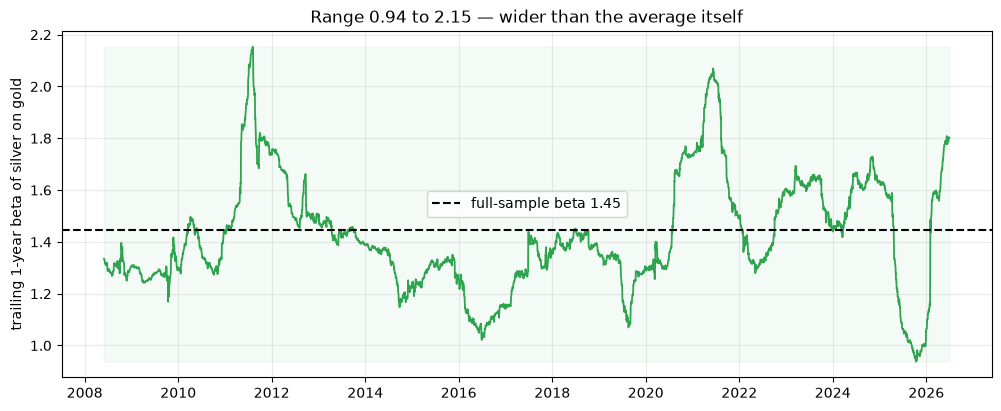

           n   mean     sd    min    max    p10    p90  range_over_mean
window                                                                 
63      4738 1.4450 0.3580 0.5420 3.1520 1.0870 1.8410           1.8060
126     4675 1.4300 0.2930 0.6960 2.7110 1.1350 1.7910           1.4090
252     4549 1.4210 0.2150 0.9380 2.1540 1.1590 1.7270           0.8560
756     4045 1.4330 0.1460 1.1960 1.7060 1.2250 1.5970           0.3560


In [3]:
rb = st.rolling_beta(s, g, 252).dropna()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(rb.index, rb, lw=1.3, color="#2ea44f")
ax.axhline(b["beta"], color="k", ls="--", lw=1.5,
           label=f"full-sample beta {b['beta']:.2f}")
ax.fill_between(rb.index, rb.min(), rb.max(), alpha=0.05, color="#2ea44f")
ax.set_ylabel("trailing 1-year beta of silver on gold"); ax.legend()
ax.set_title(f"Range {rb.min():.2f} to {rb.max():.2f} — wider than the average itself")
plt.show()
print(st.rolling_beta_table(s, g).round(3).to_string())

> \U0001F52C **For the quants.** Anyone quoting "silver's beta is 1.8" is quoting the midpoint of
> that band, which is a fact about the sample rather than a property of the asset.

## 3 · What is the other third made of?

                       n    beta       t     r2
factor                                         
dollar              4549 -0.3428 -5.4435 0.0174
real_rates          4549 -0.1044 -1.4065 0.0010
industrial          4549  0.2577 10.5848 0.0735
dollar (joint)      4549 -0.2186 -3.3546 0.0800
real_rates (joint)  4549 -0.0891 -1.1984 0.0800
industrial (joint)  4549  0.2385  8.8661 0.0800


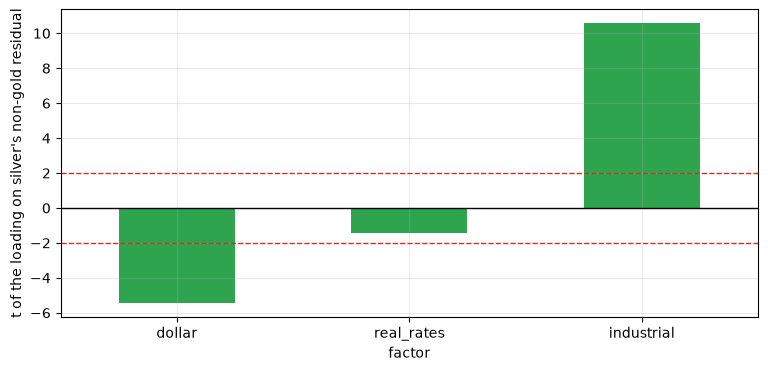

In [4]:
resid = st.residuals(s, g)
factors = pd.DataFrame({"dollar": common[data.DOLLAR], "real_rates": common[data.TIPS],
                        "industrial": common[data.INDUSTRIAL]}).reindex(resid.index)
load = st.residual_loadings(resid, factors)
print(load.round(4).to_string())
uni = load[~load.index.str.contains(r"\(joint\)")]
fig, ax = plt.subplots(figsize=(9, 4))
uni["t"].plot.bar(ax=ax, color="#2ea44f")
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("t of the loading on silver's non-gold residual")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

About half of silver demand is industrial. None of gold's is. That is the most plausible place
for the leverage story to break, and it is where this chart is looking.

## 4 · The thing nobody accounts for

Holding "2× gold" is not holding gold and doubling the return. You rebalance to 2× every day, so
you compound twice the *daily* move — and that costs you, mechanically, `β(β−1)σ²/2` a year.

In [5]:
gv = g.std() * np.sqrt(252)
for beta in (1.0, 1.5, 1.75, 2.0, 2.5, 3.0):
    print(f"{beta:.2f}x gold: volatility drag {st.leverage_drag(beta, gv):.2%} per year")
print(f"\n(gold's volatility over this sample: {gv:.1%})")

1.00x gold: volatility drag 0.00% per year
1.50x gold: volatility drag 1.23% per year
1.75x gold: volatility drag 2.16% per year
2.00x gold: volatility drag 3.28% per year
2.50x gold: volatility drag 6.16% per year
3.00x gold: volatility drag 9.85% per year

(gold's volatility over this sample: 18.1%)


## 5 · So would the replication have worked?

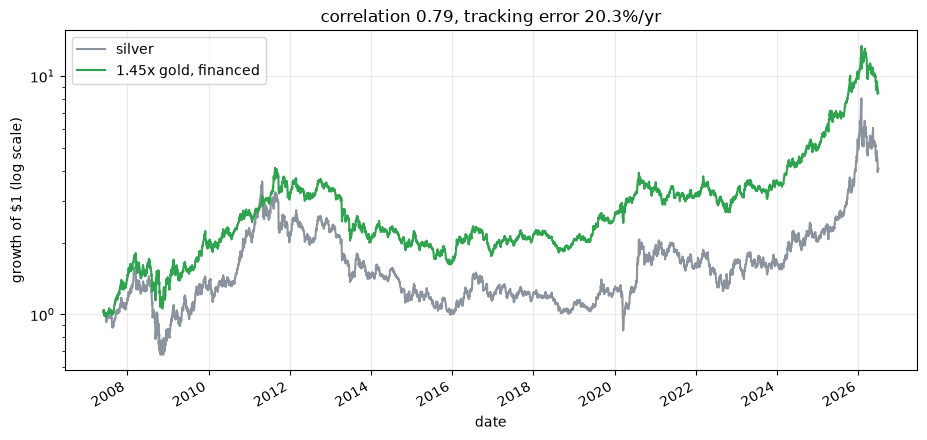

silver   CAGR +7.66%  vol 33.2%  Sharpe +0.39  maxDD -76.3%
replica  CAGR +11.89%  vol 26.2%  Sharpe +0.56  maxDD -60.7%


In [6]:
rep = st.replication_backtest(s, g, common[data.CASH], financing_spread=0.005,
                              cost_bps=1.0)
curves = (1 + rep["returns"]).cumprod()
fig, ax = plt.subplots(figsize=(11, 5))
curves.plot(ax=ax, logy=True, color=["#8b949e", "#2ea44f"])
ax.set_ylabel("growth of $1 (log scale)")
ax.legend(["silver", f"{rep['beta_used']:.2f}x gold, financed"], title="")
ax.set_title(f"correlation {rep['correlation']:.2f}, tracking error "
             f"{rep['tracking_error_ann']:.1%}/yr")
plt.show()
for k in ("silver", "replica"):
    st_ = rep[k]
    print(f"{k:8s} CAGR {st_['cagr']:+.2%}  vol {st_['vol']:.1%}  "
          f"Sharpe {st_['sharpe']:+.2f}  maxDD {st_['max_dd']:.1%}")

## 6 · The verdict

**Signal: Busted.** Regressed on gold over 4,801 sessions, silver's beta is **1.45** (±0.03) with an R² of 62% — so about 38% of silver's variance is *not* gold. That leftover is not noise. Its annualised volatility is 20.3%, and it loads on outside factors with a largest |*t*| of **10.58** (on industrial). Nor is the beta a constant: over rolling one-year windows it ranges 0.94 to 2.15, a spread of **86% of its own mean**, and it is 1.29 on gold's up days against 1.57 on its down days. 'Silver is levered gold' is a reasonable first approximation and a poor second one.

**Tradability: Useful.** Holding a 1.45× daily-rebalanced gold position instead of silver, financed at cash plus 0.5%, tracked it with a correlation of 0.79 and an annualised tracking error of **20.3%** — which is not tracking, it is a different asset. Over 19 years silver compounded at +7.7% against the replica's +11.9% (Sharpe 0.39 vs 0.56). Part of that gap is pure arithmetic: levering a 18%-vol asset 1.45× costs about **1.1% a year** in volatility drag, before financing and before costs.

## 7 · Going further \U0001F6AA

- **Physical demand data.** The *World Silver Survey* splits demand into industrial, investment
  and jewellery. Photovoltaics went from a rounding error to a fifth of silver demand across
  this sample — a daily price feed cannot see that, and it is probably the main story.
- **Monthly rebalancing** instead of daily would cut the volatility drag substantially and is
  the fairer version of the replication.
- **The miners lever it again.** GDX and SIL are levered bets on levered bets, with their own
  residual — a natural next study.